# 1. Introduction
Data plays a vital role in helping organizations understand market trends, evaluate business performance, and make 
informed decisions. Web scraping is an efficient technique for collecting publicly available data from websites, 
enabling analysts to build datasets for further analysis. This project uses web scraping and exploratory data analysis to
examine information from 100 companies and identify meaningful insights from the collected data.

# 2. Project Overview

This internship project aims to analyze a dataset of the top 100 companies collected through web scraping using Python's BeautifulSoup library. The dataset contains information on each company's Rank, Name, Industry, Revenue (USD millions), Revenue Growth (%), Number of Employees, and Headquarters. After collecting the data, it was cleaned and preprocessed to ensure accuracy and consistency. Exploratory Data Analysis (EDA) was then performed to examine the dataset, summarize its key characteristics, identify trends and patterns, and explore relationships among the variables.

# 3. Tools used 

The project was completed using Python as the primary programming language. BeautifulSoup was used to scrape company data from web pages, while Pandas was used for data cleaning, manipulation, and exploratory data analysis. Matplotlib and Seaborn were used to create visualizations that helped identify trends and patterns in the data. Jupyter Notebook served as the development environment for writing, executing, and documenting the analysis.  

# 4.Dataset Description

The dataset consists of information on 100 companies collected through web scraping using Python's BeautifulSoup library. 
It contains seven variables: Company Rank, Company Name, Industry, Revenue (USD millions), Revenue Growth (%), 
Employees, and Headquarters. 

Before analysis, the dataset was cleaned by removing inconsistencies, checking for missing values and duplicate records, 
and verifying the data types to ensure accuracy and consistency.

 

In [47]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [48]:
# url
url = "https://en.wikipedia.org/wiki/List_of_largest_companies_in_the_United_States_by_revenue"

In [49]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

In [50]:
# Send HTTP request

page = requests.get(url, headers=headers)

In [51]:
print(page)

<Response [200]>


In [119]:
#  Parse HTML

soup =BeautifulSoup(page.text, 'html.parser')

In [53]:
# Find all wikitable tables

tables = soup.find_all("table", class_="wikitable sortable")

In [121]:
# The first sortable table contains the company data

table = tables[0]

In [55]:
# Extract headers

headers = [th.get_text(strip=True) for th in table.find("tr").find_all("th")]

In [56]:
headers 

['Rank',
 'Name',
 'Industry',
 'Revenue(USD millions)',
 'Revenue growth',
 'Employees',
 'Headquarters']

In [57]:
# Extract rows
rows = []
for tr in table.find_all("tr")[1:]:
    cells = tr.find_all(["th", "td"])
    row = [cell.get_text(strip=True) for cell in cells]

    if row:
        rows.append(row)


In [58]:
# Create DataFrame
df = pd.DataFrame(rows, columns=headers)

In [59]:
# Save to CSV

df.to_csv("largest_us_companies.csv", index=False)

In [60]:
print("Data saved successfully!")

Data saved successfully!


In [61]:
# Check that the file was created

import os

os.listdir()

['.ipynb_checkpoints',
 'Clean_companies.csv',
 'largest_us_companies.csv',
 'Web_Scraping_using_BeautifulSoup_&_EDA.ipynb']

In [62]:
# Display first 5 rows
df.head()

,Rank,Name,Industry,Revenue(USD millions),Revenue growth,Employees,Headquarters
0,1,Walmart,Retail,"680,985",5.1%,"2,100,000","Bentonville, Arkansas"
1,2,Amazon,Retail and cloud computing,"637,959",11.0%,"1,556,000","Seattle, Washington"
2,3,UnitedHealth Group,Healthcare,"400,278",7.7%,"400,000","Minnetonka, Minnesota"
3,4,Apple,Technology,"391,035",2.0%,"164,000","Cupertino, California"
4,5,CVS Health,Healthcare,"372,809",4.2%,"259,500","Woonsocket, Rhode Island"


# 5. Data Cleaning

The scraped dataset was cleaned and preprocessed before analysis. Missing values and duplicate records were checked to ensure data quality. The Rank column was converted to an integer data type, while the numerical columns, including Revenue (USD millions), Revenue Growth (%), and Number of Employees, were converted to appropriate numeric data types to enable accurate analysis. Finally, the data types were verified to ensure the dataset was ready for exploratory data analysis (EDA)

In [63]:
df.shape

(100, 7)

In [64]:
df.columns

Index(['Rank', 'Name', 'Industry', 'Revenue(USD millions)', 'Revenue growth',
       'Employees', 'Headquarters'],
      dtype='object')

In [65]:
df.dtypes

Rank                     object
Name                     object
Industry                 object
Revenue(USD millions)    object
Revenue growth           object
Employees                object
Headquarters             object
dtype: object

In [66]:
# convert Rank data tpye to integer
df["Rank"] = df["Rank"].astype(int)

In [67]:

df["Rank"] 

0       1
1       2
2       3
3       4
4       5
     ... 
95     96
96     97
97     98
98     99
99    100
Name: Rank, Length: 100, dtype: int32

In [68]:
df.dtypes

Rank                      int32
Name                     object
Industry                 object
Revenue(USD millions)    object
Revenue growth           object
Employees                object
Headquarters             object
dtype: object

In [69]:
# Convert the numeric columns
df["Revenue(USD millions)"] = (
    df["Revenue(USD millions)"]
    .str.replace(",", "")
    .str.replace("$", "")
    .astype(float)
)

In [70]:
df.dtypes

Rank                       int32
Name                      object
Industry                  object
Revenue(USD millions)    float64
Revenue growth            object
Employees                 object
Headquarters              object
dtype: object

In [71]:
df.head()

,Rank,Name,Industry,Revenue(USD millions),Revenue growth,Employees,Headquarters
0,1,Walmart,Retail,680985.0,5.1%,"2,100,000","Bentonville, Arkansas"
1,2,Amazon,Retail and cloud computing,637959.0,11.0%,"1,556,000","Seattle, Washington"
2,3,UnitedHealth Group,Healthcare,400278.0,7.7%,"400,000","Minnetonka, Minnesota"
3,4,Apple,Technology,391035.0,2.0%,"164,000","Cupertino, California"
4,5,CVS Health,Healthcare,372809.0,4.2%,"259,500","Woonsocket, Rhode Island"


In [72]:
# Convert to numeric
df["Revenue growth"] = (
    df["Revenue growth"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

# Rename the column
df.rename(columns={"Revenue growth": "Revenue growth (%)"}, inplace=True)

In [73]:
df.head()

,Rank,Name,Industry,Revenue(USD millions),Revenue growth (%),Employees,Headquarters
0,1,Walmart,Retail,680985.0,5.1,"2,100,000","Bentonville, Arkansas"
1,2,Amazon,Retail and cloud computing,637959.0,11.0,"1,556,000","Seattle, Washington"
2,3,UnitedHealth Group,Healthcare,400278.0,7.7,"400,000","Minnetonka, Minnesota"
3,4,Apple,Technology,391035.0,2.0,"164,000","Cupertino, California"
4,5,CVS Health,Healthcare,372809.0,4.2,"259,500","Woonsocket, Rhode Island"


In [74]:
# Employees
df["Employees"] = (
    df["Employees"]
    .str.replace(",", "", regex=False)
    .astype(int)
)

In [75]:
df.dtypes

Rank                       int32
Name                      object
Industry                  object
Revenue(USD millions)    float64
Revenue growth (%)       float64
Employees                  int32
Headquarters              object
dtype: object

In [76]:
df

,Rank,Name,Industry,Revenue(USD millions),Revenue growth (%),Employees,Headquarters
0,1,Walmart,Retail,680985.0,5.1,2100000,"Bentonville, Arkansas"
1,2,Amazon,Retail and cloud computing,637959.0,11.0,1556000,"Seattle, Washington"
2,3,UnitedHealth Group,Healthcare,400278.0,7.7,400000,"Minnetonka, Minnesota"
3,4,Apple,Technology,391035.0,2.0,164000,"Cupertino, California"
4,5,CVS Health,Healthcare,372809.0,4.2,259500,"Woonsocket, Rhode Island"
...,...,...,...,...,...,...,...
95,96,General Dynamics,Aerospace and defense,47716.0,12.9,117000,"Reston, Virginia"
96,97,Coca-Cola,Beverage,47061.0,2.9,69700,"Atlanta, Georgia"
97,98,TIAA,Financials,46946.0,2.6,15623,"New York City, New York"
98,99,Travelers,Insurance,46423.0,12.2,34000,"New York City, New York"


In [77]:
df.to_csv("Clean_companies.csv", index=False)

In [78]:
import os

os.listdir()

['.ipynb_checkpoints',
 'Clean_companies.csv',
 'largest_us_companies.csv',
 'Web_Scraping_using_BeautifulSoup_&_EDA.ipynb']

# Exploratory Data Analysis (EDA).

In [79]:
df.describe()


,Rank,Revenue(USD millions),Revenue growth (%),Employees
count,100.000000,100.00000,100.000000,1.000000e+02
mean,50.500000,130499.62000,7.689000,1.619777e+05
std,29.011492,116235.76346,15.258201,2.682762e+05
min,1.000000,45043.00000,-15.600000,4.200000e+03
25%,25.750000,56804.75000,0.900000,4.475000e+04
50%,50.500000,84784.50000,5.050000,8.570000e+04
75%,75.250000,148911.00000,11.125000,1.886625e+05
max,100.000000,680985.00000,114.200000,2.100000e+06


# Revenue (USD millions)

## Observation

- The dataset contains 100 companies
- The average company revenue is 130,499.62 million USD.
- Average revenue growth is 7.69%.
- Average workforce size is approximately 161,978 employees.
- Revenue ranges from 45,043 million USD to 680,985 million USD.
- The median revenue (84,784.50 million USD) is much lower than the mean
- Employee counts range from 4,200 to 2.1 million

## Insight

The mean revenue is significantly higher than the median revenue, indicating that a small number of companies generate exceptionally high revenues, which increase the overall average. This suggests that the revenue distribution is positively skewed and may contain high-value outliers.The Interquartile Range (IQR) method can be used to determine whether these values are statistical outliers.

On average, companies experienced positive revenue growth. However, the relatively high standard deviation (15.26%) and the maximum growth rate of 114.2% indicate substantial variation in growth performance across companies. This suggests that while many companies achieved moderate growth, a few experienced exceptionally high growth rates.

# Checking for Outlier¶

1. Get Q1
2. Get Q3
3. Calculate IQR
4. Calculate Lower Bound
5. Calculate Upper Bound
6. Check for outliers

In [80]:
Q1 = df["Revenue(USD millions)"].quantile(0.25)
Q3 = df["Revenue(USD millions)"].quantile(0.75)

In [81]:
Q1 

56804.75

In [82]:
Q3

148911.0

## Calculate the IQR

In [83]:
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 56804.75
Q3: 148911.0
IQR: 92106.25


# Calculate the lower and upper limits

In [84]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -81354.625
Upper Bound: 287070.375


In [85]:
outliers = df[
    (df["Revenue(USD millions)"] < lower_bound) |
    (df["Revenue(USD millions)"] > upper_bound)
]

In [107]:
outliers[["Name", "Industry", "Revenue(USD millions)"]]

,Name,Industry,Revenue(USD millions)
0,Walmart,Retail,680985.0
1,Amazon,Retail and cloud computing,637959.0
2,UnitedHealth Group,Healthcare,400278.0
3,Apple,Technology,391035.0
4,CVS Health,Healthcare,372809.0
5,Berkshire Hathaway,Conglomerate,371433.0
6,Alphabet,Technology and cloud computing,350018.0
7,Exxon Mobil,Petroleum,349595.0
8,McKesson Corporation,Healthcare,308951.0
9,Cencora,Pharmacy wholesale,293959.0


The IQR method identified 10 companies as revenue outliers. 
These companies have revenues above the upper bound (Q3 + 1.5 × IQR), indicating that they generate substantially higher 
revenues than the majority of companies in the dataset. These high-revenue companies contribute to the positive skewness of 
the revenue distribution and increase the overall mean revenue. Since these companies are among the largest corporations in the
United States, these outliers represent genuine business observations rather than data errors.

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [88]:
df["Industry"].value_counts()

Industry
Financials                             16
Retail                                  9
Technology                              9
Petroleum                               9
Healthcare                              7
Insurance                               6
Pharmaceutical                          5
Aerospace and defense                   4
Airline                                 3
Technology and cloud computing          3
Food processing                         3
Telecommunications                      3
Transportation                          2
Pharmaceutical industry                 2
Beverage                                2
Automotive                              2
Health insurance                        2
Retail and cloud computing              1
Media                                   1
Automotive and energy                   1
Food industry                           1
Consumer products manufacturing         1
Conglomerate and telecommunications     1
Machinery                

In [89]:
df.groupby("Industry")["Headquarters"].count()

Industry
Aerospace and defense                   4
Agriculture manufacturing               1
Airline                                 3
Apparel                                 1
Automotive                              2
Automotive and energy                   1
Beverage                                2
Conglomerate                            1
Conglomerate and telecommunications     1
Consumer products manufacturing         1
Financials                             16
Food industry                           1
Food processing                         3
Health insurance                        2
Healthcare                              7
Information Technology                  1
Insurance                               6
Machinery                               1
Media                                   1
Petroleum                               9
Pharmaceutical                          5
Pharmaceutical industry                 2
Pharmacy wholesale                      1
Retail                   

In [90]:
# Average revenue by industry
df.groupby("Industry")["Revenue(USD millions)"].mean().sort_values(ascending=False)

Industry
Retail and cloud computing             637959.000000
Conglomerate                           371433.000000
Pharmacy wholesale                     293959.000000
Healthcare                             245650.000000
Technology and cloud computing         219297.666667
Automotive                             186217.000000
Health insurance                       182441.000000
Retail                                 180898.888889
Petroleum                              134242.777778
Conglomerate and telecommunications    122336.000000
Financials                             117144.687500
Technology                             115737.444444
Telecommunications                     104534.666667
Automotive and energy                   97690.000000
Media                                   91361.000000
Transportation                          89381.500000
Food industry                           85530.000000
Consumer products manufacturing         84039.000000
Pharmaceutical                       

In [91]:
# Average Employees by Industry
avg_emp= df.groupby("Industry")["Employees"].mean().sort_values(ascending=False)
print(avg_emp.apply(lambda x: f"{x:,.0f}"))

Industry
Retail and cloud computing             1,556,000
Retail                                   531,472
Transportation                           397,140
Conglomerate                             392,400
Technology and cloud computing           231,941
Media                                    205,040
Beverage                                 194,350
Healthcare                               170,156
Automotive                               166,500
Aerospace and defense                    149,000
Conglomerate and telecommunications      140,990
Automotive and energy                    125,665
Telecommunications                       125,367
Airline                                  114,533
Machinery                                112,900
Consumer products manufacturing          108,000
Pharmaceutical                           105,340
Telecom hardware manufacturing            90,400
Financials                                89,978
Technology                                85,677
Food proces

In [95]:
# Average revenue growth by industry
df.groupby("Industry")["Revenue growth (%)"]\
.mean()\
.sort_values(ascending=False)

Industry
Technology                             21.788889
Health insurance                       18.650000
Financials                             15.206250
Pharmacy wholesale                     12.100000
Insurance                              11.900000
Retail and cloud computing             11.000000
Technology and cloud computing         10.333333
Pharmaceutical                          8.500000
Pharmaceutical industry                 7.750000
Healthcare                              7.442857
Automotive                              7.050000
Aerospace and defense                   5.150000
Airline                                 5.033333
Media                                   2.800000
Consumer products manufacturing         2.500000
Food processing                         2.200000
Retail                                  2.155556
Conglomerate                            1.900000
Beverage                                1.650000
Information Technology                  1.600000
Telecommuni

# Hypothesis Question: Is there a statistically significant relationship between Employees and Revenue(USD millions)?

In [96]:
from scipy.stats import pearsonr

# Calculate correlation coefficient and p-value
correlation, p_value = pearsonr(
    df["Employees"],
    df["Revenue(USD millions)"]
)

# Print results
print("Correlation coefficient (r) between Employees and Revenue:", correlation)
print("P-value:", p_value)

# Test significance
if p_value < 0.05:
    print("P-value is less than 0.05: The relationship is statistically significant.")
else:
    print("P-value is greater than or equal to 0.05: The relationship is not statistically significant.")

Correlation coefficient (r) between Employees and Revenue: 0.6902252639954785
P-value: 1.9593669204482977e-15
P-value is less than 0.05: The relationship is statistically significant.


The Pearson correlation test produced a p-value of approximately 1.96 × 10⁻¹⁵, which is below the 0.05 significance level. 
Therefore, there is strong statistical evidence of a significant relationship between employee count and revenue.

In [97]:
df["Employees"].corr(df["Revenue growth (%)"])

-0.08115407586447401

The correlation between employees and revenue growth was -0.08, indicating a very weak negative relationship. 
This suggests that employee size has little to no linear relationship with revenue growth. 
Company growth is likely influenced by other factors such as market conditions, innovation, industry, and business strategy.

# For your EDA conclusion
Employee count shows a positive relationship with revenue (r = 0.69), suggesting that larger companies tend to generate higher
revenue because they have greater operational capacity. However, employee count has almost no relationship with revenue growth
(r = -0.08), indicating that workforce size alone does not determine future growth."

# Revenue Distribution

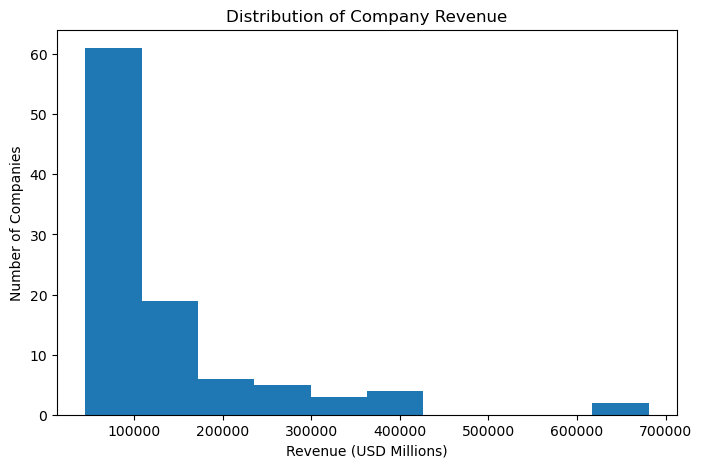

In [99]:
plt.figure(figsize=(8,5))
plt.hist(df["Revenue(USD millions)"], bins=10)

plt.title("Distribution of Company Revenue")
plt.xlabel("Revenue (USD Millions)")
plt.ylabel("Number of Companies")
plt.show()

(array([61., 19.,  6.,  5.,  3.,  4.,  0.,  0.,  0.,  2.]),
 array([ 45043. , 108637.2, 172231.4, 235825.6, 299419.8, 363014. ,
        426608.2, 490202.4, 553796.6, 617390.8, 680985. ]),
 <BarContainer object of 10 artists>)

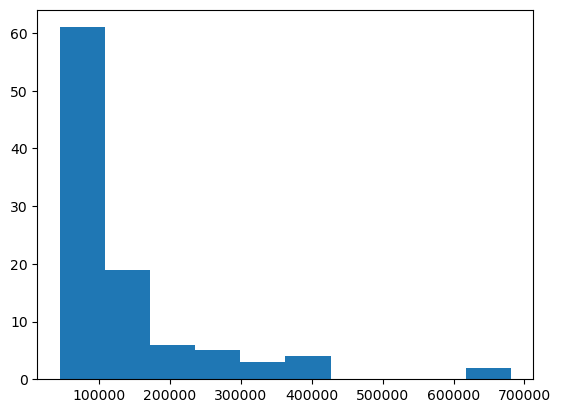

In [100]:
plt.hist(df["Revenue(USD millions)"])

# Observation
The histogram shows that company revenue is not evenly distributed. 
Most companies are concentrated in the lower revenue range, with 61 out of 100 companies having revenues 
between 45,043 and 108,637.2 million USD, while 19 companies have revenues between 108,637.2 and 172,231.4 million USD.
As revenue increases, the number of companies decreases, resulting in a positively (right) skewed distribution. 
This suggests that only a small number of companies generate exceptionally high revenues.

Insight

- Revenue is not evenly distributed across companies.
- Most companies fall within the lowest revenue interval.
- A few companies have exceptionally high revenues.

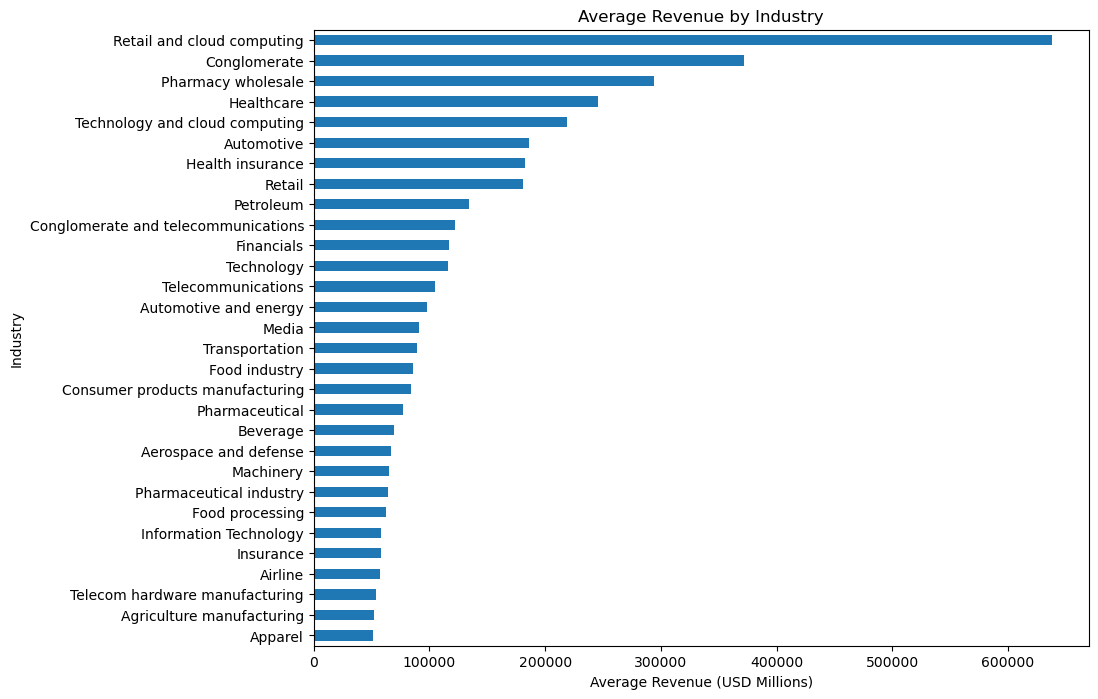

In [104]:
industry_rev = df.groupby("Industry")["Revenue(USD millions)"].mean().sort_values()

plt.figure(figsize=(10,8))

industry_rev.plot(kind="barh")

plt.title("Average Revenue by Industry")
plt.xlabel("Average Revenue (USD Millions)")
plt.ylabel("Industry")

plt.show()

# Observation:

- Retail and cloud computing has the highest average revenue, followed by Conglomerates and Pharmacy wholesale.
- Apparel, Agriculture manufacturing, and Airline industries have the lowest average revenues.
- Average revenue varies considerably across industries.

## Insight:

- Industry is a key factor influencing company revenue.
- Technology- and retail-related industries tend to generate significantly higher revenues than traditional manufacturing and service sectors.
- Additional metrics such as profit, revenue growth, and company count should be analyzed to obtain a more comprehensive understanding of industry performance.

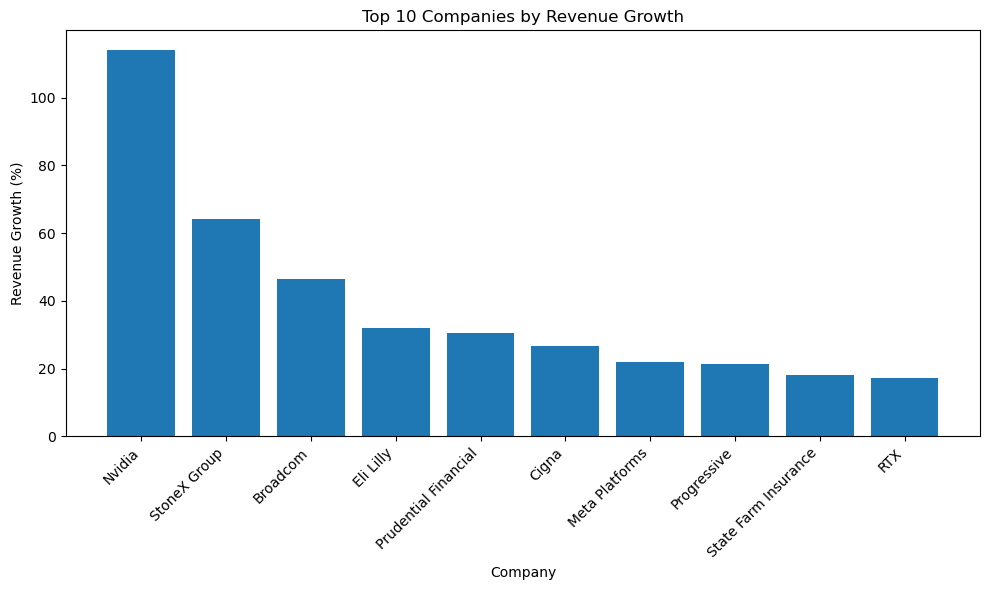

In [110]:
top10_growth = df.nlargest(10, "Revenue growth (%)")

plt.figure(figsize=(10,6))

plt.bar(top10_growth["Name"], top10_growth["Revenue growth (%)"])

plt.xticks(rotation=45, ha="right")

plt.xlabel("Company")
plt.ylabel("Revenue Growth (%)")
plt.title("Top 10 Companies by Revenue Growth")

plt.tight_layout()
plt.show()

# Observation

Nvidia recorded the highest revenue growth (approximately 114%), followed by StoneX Group (64%) and Broadcom (47%). 
Revenue growth decreases steadily across the remaining companies, with RTX recording the lowest growth among the top ten. 
Nvidia stands out as a clear outlier due to its exceptionally high growth.


# Insight
The analysis indicates that only a few companies achieved exceptionally high revenue growth, with Nvidia significantly 
outperforming the rest of the top ten. This suggests that strong revenue growth is concentrated among a small number of
companies, while most high-performing companies experienced moderate growth. Organizations can learn from the strategies
of these leading firms, but revenue growth should be assessed alongside profitability and other financial indicators to obtain
a complete picture of business performance.

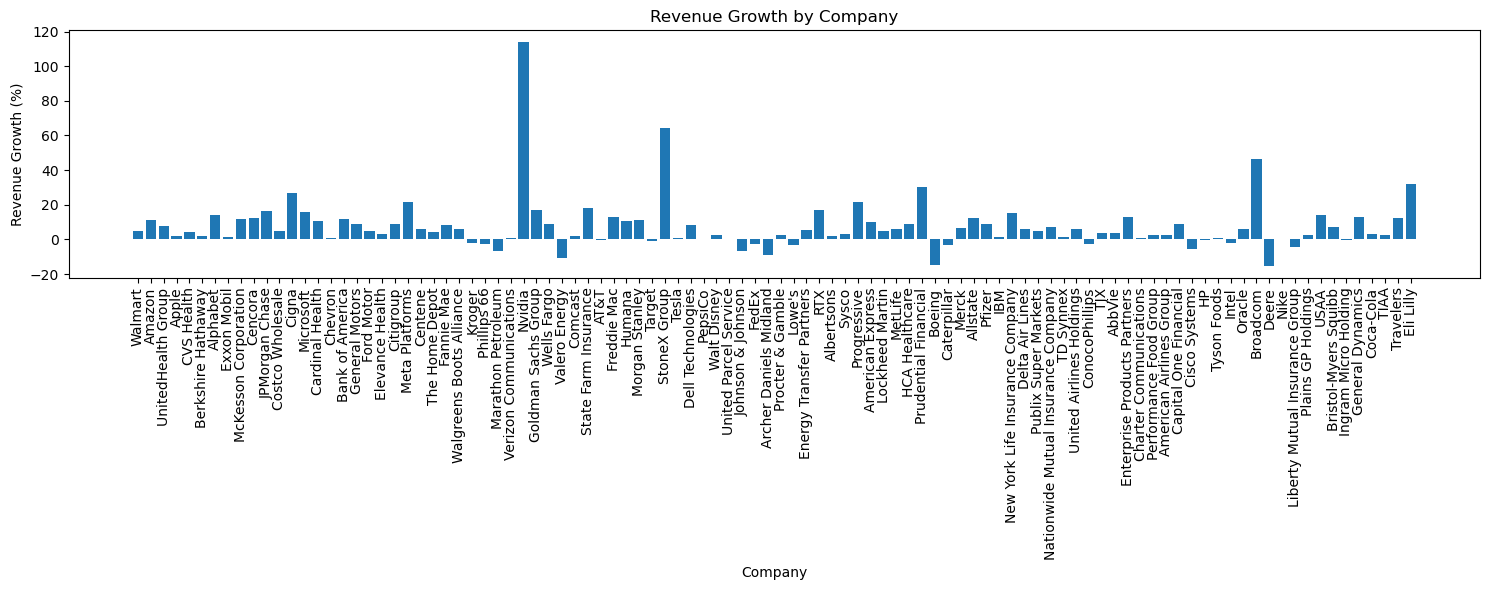

In [108]:
plt.figure(figsize=(15,6))

plt.bar(df["Name"], df["Revenue growth (%)"])

plt.xticks(rotation=90)

plt.xlabel("Company")
plt.ylabel("Revenue Growth (%)")
plt.title("Revenue Growth by Company")

plt.tight_layout()
plt.show()

In [115]:
sorted_df

,Rank,Name,Industry,Revenue(USD millions),Revenue growth (%),Employees,Headquarters
30,31,Nvidia,Technology,130497.0,114.2,36000,"Santa Clara, California"
41,42,StoneX Group,Financials,99888.0,64.1,4500,"New York City, New York"
87,88,Broadcom,Technology,52432.0,46.4,37000,"Palo Alto, California"
99,100,Eli Lilly,Pharmaceutical,45043.0,32.0,47000,"Indianapolis, Indiana"
61,62,Prudential Financial,Financials,70405.0,30.4,37936,"Newark, New Jersey"
...,...,...,...,...,...,...,...
47,48,Johnson & Johnson,Pharmaceutical,88821.0,-6.7,138100,"New Brunswick, New Jersey"
49,50,Archer Daniels Midland,Food industry,85530.0,-8.9,43213,"Chicago, Illinois"
33,34,Valero Energy,Petroleum,123974.0,-10.8,9910,"San Antonio, Texas"
62,63,Boeing,Aerospace and defense,66517.0,-14.5,172000,"Arlington County, Virginia"


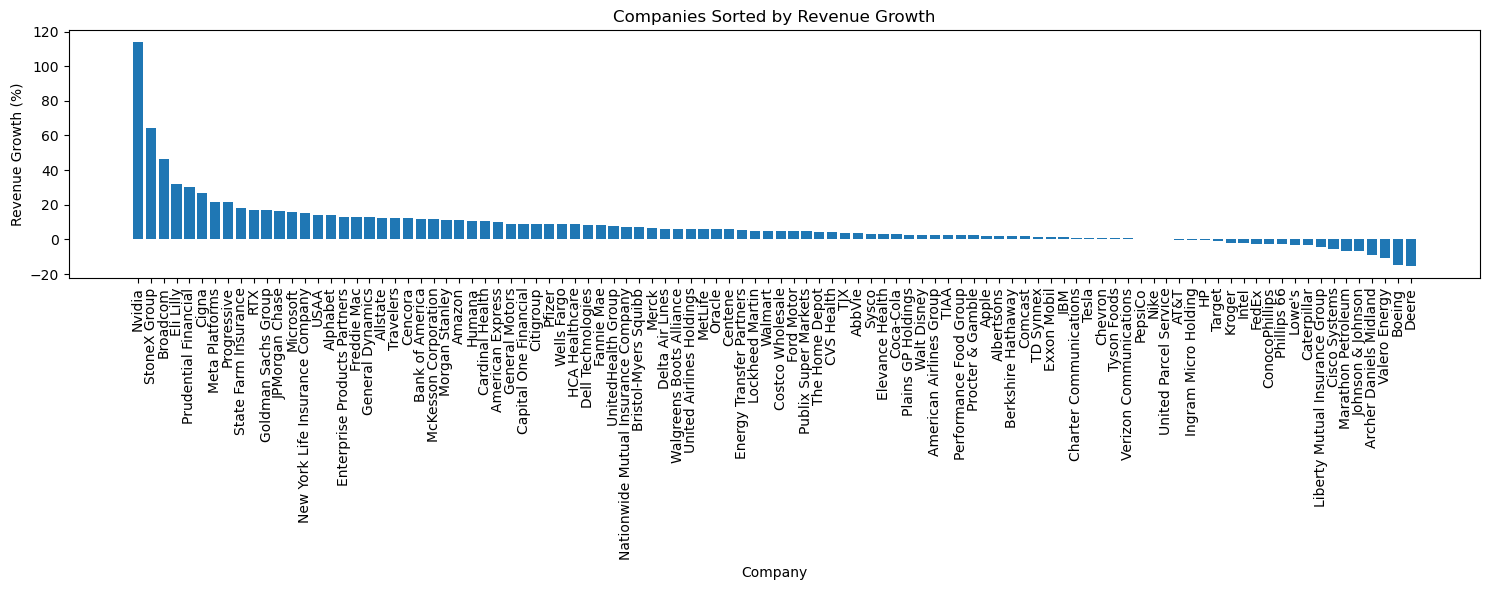

In [111]:
sorted_df = df.sort_values(by="Revenue growth (%)", ascending=False)

plt.figure(figsize=(15,6))

plt.bar(sorted_df["Name"], sorted_df["Revenue growth (%)"])

plt.xticks(rotation=90)

plt.xlabel("Company")
plt.ylabel("Revenue Growth (%)")
plt.title("Companies Sorted by Revenue Growth")

plt.tight_layout()
plt.show()

# Observation 

This chart indicates that Nvidia recorded the highest revenue growth of approximately 114%, significantly outperforming all other companies.

StoneX Group recorded a revenue growth of approximately 65%, making it the second-best-performing company in terms of revenue growth.

Broadcom recorded a revenue growth of approximately 22%, indicating solid business expansion during the reporting period.

Toward the right side of the chart, several companies recorded negative revenue growth, indicating a decline in revenue compared
to the previous period. Deere experienced the largest decline at approximately 15%, followed by Boeing, Valero Energy, 
Archer-Daniels-Midland, Kimberly-Clark, Marathon Petroleum, and Cisco Systems, all of which also reported negative 
revenue growth.

## insight 

The chart highlights substantial differences in revenue growth among the selected companies.
Nvidia emerged as the strongest performer with exceptional revenue growth, while several companies experienced negative growth. 
This suggests that company performance was uneven during the reporting period, with only a few firms achieving outstanding
growth while others faced declining revenues.

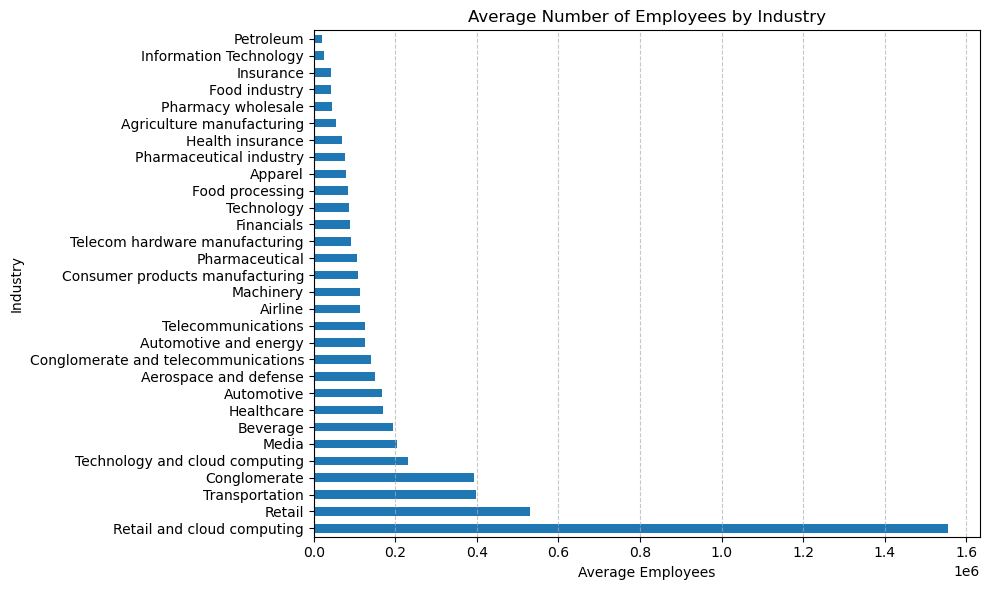

In [114]:
plt.figure(figsize=(10,6))
avg_emp.plot(kind='barh')

plt.title("Average Number of Employees by Industry")
plt.xlabel("Average Employees")
plt.ylabel("Industry")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Observation
The analysis of the average number of employees by industry demonstrates significant differences in workforce size across industries.
The Retail and cloud computing industry has the largest average workforce, with approximately 1.56 million employees.
This may be due to the fact that retail operations require a large workforce, while large-scale cloud service providers also
employ many people to support their extensive business operations.

The Retail and Transportation industries also employ a large number of workers on average. 
In contrast, industries such as Petroleum, Information Technology, and Insurance have considerably smaller average workforces.
Overall, the findings indicate that workforce requirements differ substantially depending on the operational characteristics
and scale of each industry.


# Insight

- The Retail and cloud computing industry has the highest average number of employees (approximately 1.56 million), making it a clear outlier compared to all other industries.

- After Retail and cloud computing, the Retail and Transportation industries have the next highest number of average employee . This suggests that these industries generally require more employees to support their operations.

- Industries such as Petroleum, Information Technology, Insurance, and Food industry have much lower average employee . This indicates that companies in these industries generally operate with smaller workforces.